In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# Read the df
df = pd.read_csv('../data/train.csv')
print(f"df shape: {df.shape}")
df.sample(5)

df shape: (891216, 16)


C:\Users\Akhil\AppData\Local\Temp\ipykernel_6352\777548732.py:2: DtypeWarning: Columns (0: PRN, 1: Carrier_Doppler_hz, 2: Pseudorange_m, 3: RX_time, 4: TOW, 5: Carrier_phase, 6: EC, 7: LC, 8: PC, 9: PIP, 10: PQP, 11: TCD, 12: CN0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/train.csv')


,time,channel,PRN,Carrier_Doppler_hz,Pseudorange_m,RX_time,TOW,Carrier_phase,EC,LC,PC,PIP,PQP,TCD,CN0,spoofed
240044,30005,ch4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
671527,83940,ch7,0,0.0,0.0,175182.46,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
298549,37318,ch5,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
519333,64916,ch5,0,0.0,0.0,174801.98,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
254401,31800,ch1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [3]:
df.shape

(891216, 16)

In [4]:
df.columns

Index(['time', 'channel', 'PRN', 'Carrier_Doppler_hz', 'Pseudorange_m',
       'RX_time', 'TOW', 'Carrier_phase', 'EC', 'LC', 'PC', 'PIP', 'PQP',
       'TCD', 'CN0', 'spoofed'],
      dtype='str')

In [5]:
df.isnull().sum()
# No missing data

time                  0
channel               0
PRN                   0
Carrier_Doppler_hz    0
Pseudorange_m         0
RX_time               0
TOW                   0
Carrier_phase         0
EC                    0
LC                    0
PC                    0
PIP                   0
PQP                   0
TCD                   0
CN0                   0
spoofed               0
dtype: int64

In [6]:
print("Start Time",df["time"].min())
print("End Time",df["time"].max())

Start Time 0
End Time 111401


Imbalanced classes 

In [7]:
df['spoofed'].value_counts()

spoofed
0    763888
1    127328
Name: count, dtype: int64

In [8]:
# First 8 rows are initializatiion rows and contain no information 
df['PRN'][8:].unique()

array(['0', '6', '2', '12', '19', 6, 0, 12, 19, 25, 11, 2, 17, 3, 24, 26,
       16, 9, 31, 4, 27, 8, 7, 20], dtype=object)

As some channels have datatype string instead of int they will be converted into integer and also drop the first 8 initialization rows

In [9]:
# Drop initialization rows
df = df[~df['PRN'].astype(str).str.startswith('ch')].reset_index(drop=True)

# Convert ALL columns to numeric
cols_to_convert = ['time', 'PRN', 'Carrier_Doppler_hz', 'Pseudorange_m', 
                   'RX_time', 'TOW', 'Carrier_phase', 
                   'EC', 'LC', 'PC', 'PIP', 'PQP', 'TCD', 'CN0']

df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors='coerce')

# PRN and channel should be integers specifically
df['PRN'] = df['PRN'].astype(int)

In [10]:
df['PRN'][8:].unique()

array([ 0,  6,  2, 12, 19, 25, 11, 17,  3, 24, 26, 16,  9, 31,  4, 27,  8,
        7, 20])

In [11]:
df['channel'].unique()

<StringArray>
['ch0', 'ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6', 'ch7']
Length: 8, dtype: str

Early-Late Correlator Differnce(ELCD)=(EC − LC) / PC

In [12]:
df['ELCD']=(df['EC']-df['LC'])/df['PC']

In a genuine signal, EC ≈ LC . Spoofing distorts this symmetry because the fake signal's code structure is subtly different. The ratio (EC-LC)/PC are powerful spoofing indicators. Sudden changes in the ratio and huge deflecton from 0 is a indictor for a fake signal.

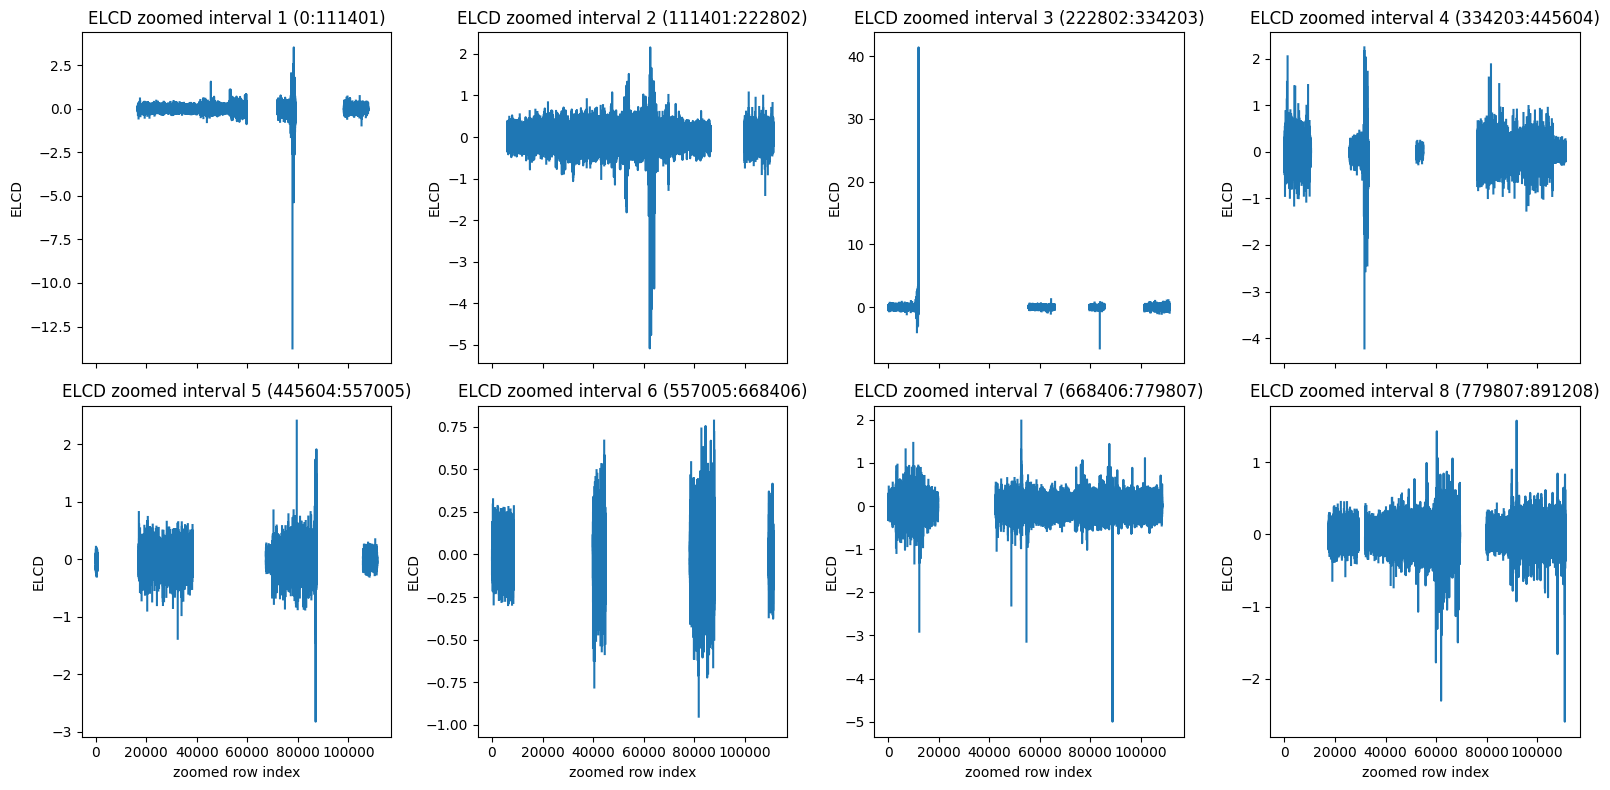

In [13]:
interval_count = 8
interval_len = len(df) // interval_count
fig, axs = plt.subplots(2, 4, figsize=(16, 8), sharex=True)
axs = axs.flatten()

for i in range(interval_count):
    start = i * interval_len
    end = start + interval_len
    axs[i].plot(df['ELCD'].iloc[start:end].reset_index(drop=True))
    axs[i].set_title(f'ELCD zoomed interval {i + 1} ({start}:{end})')
    axs[i].set_ylabel('ELCD')

for ax in axs[4:]:
    ax.set_xlabel('zoomed row index')

plt.tight_layout()

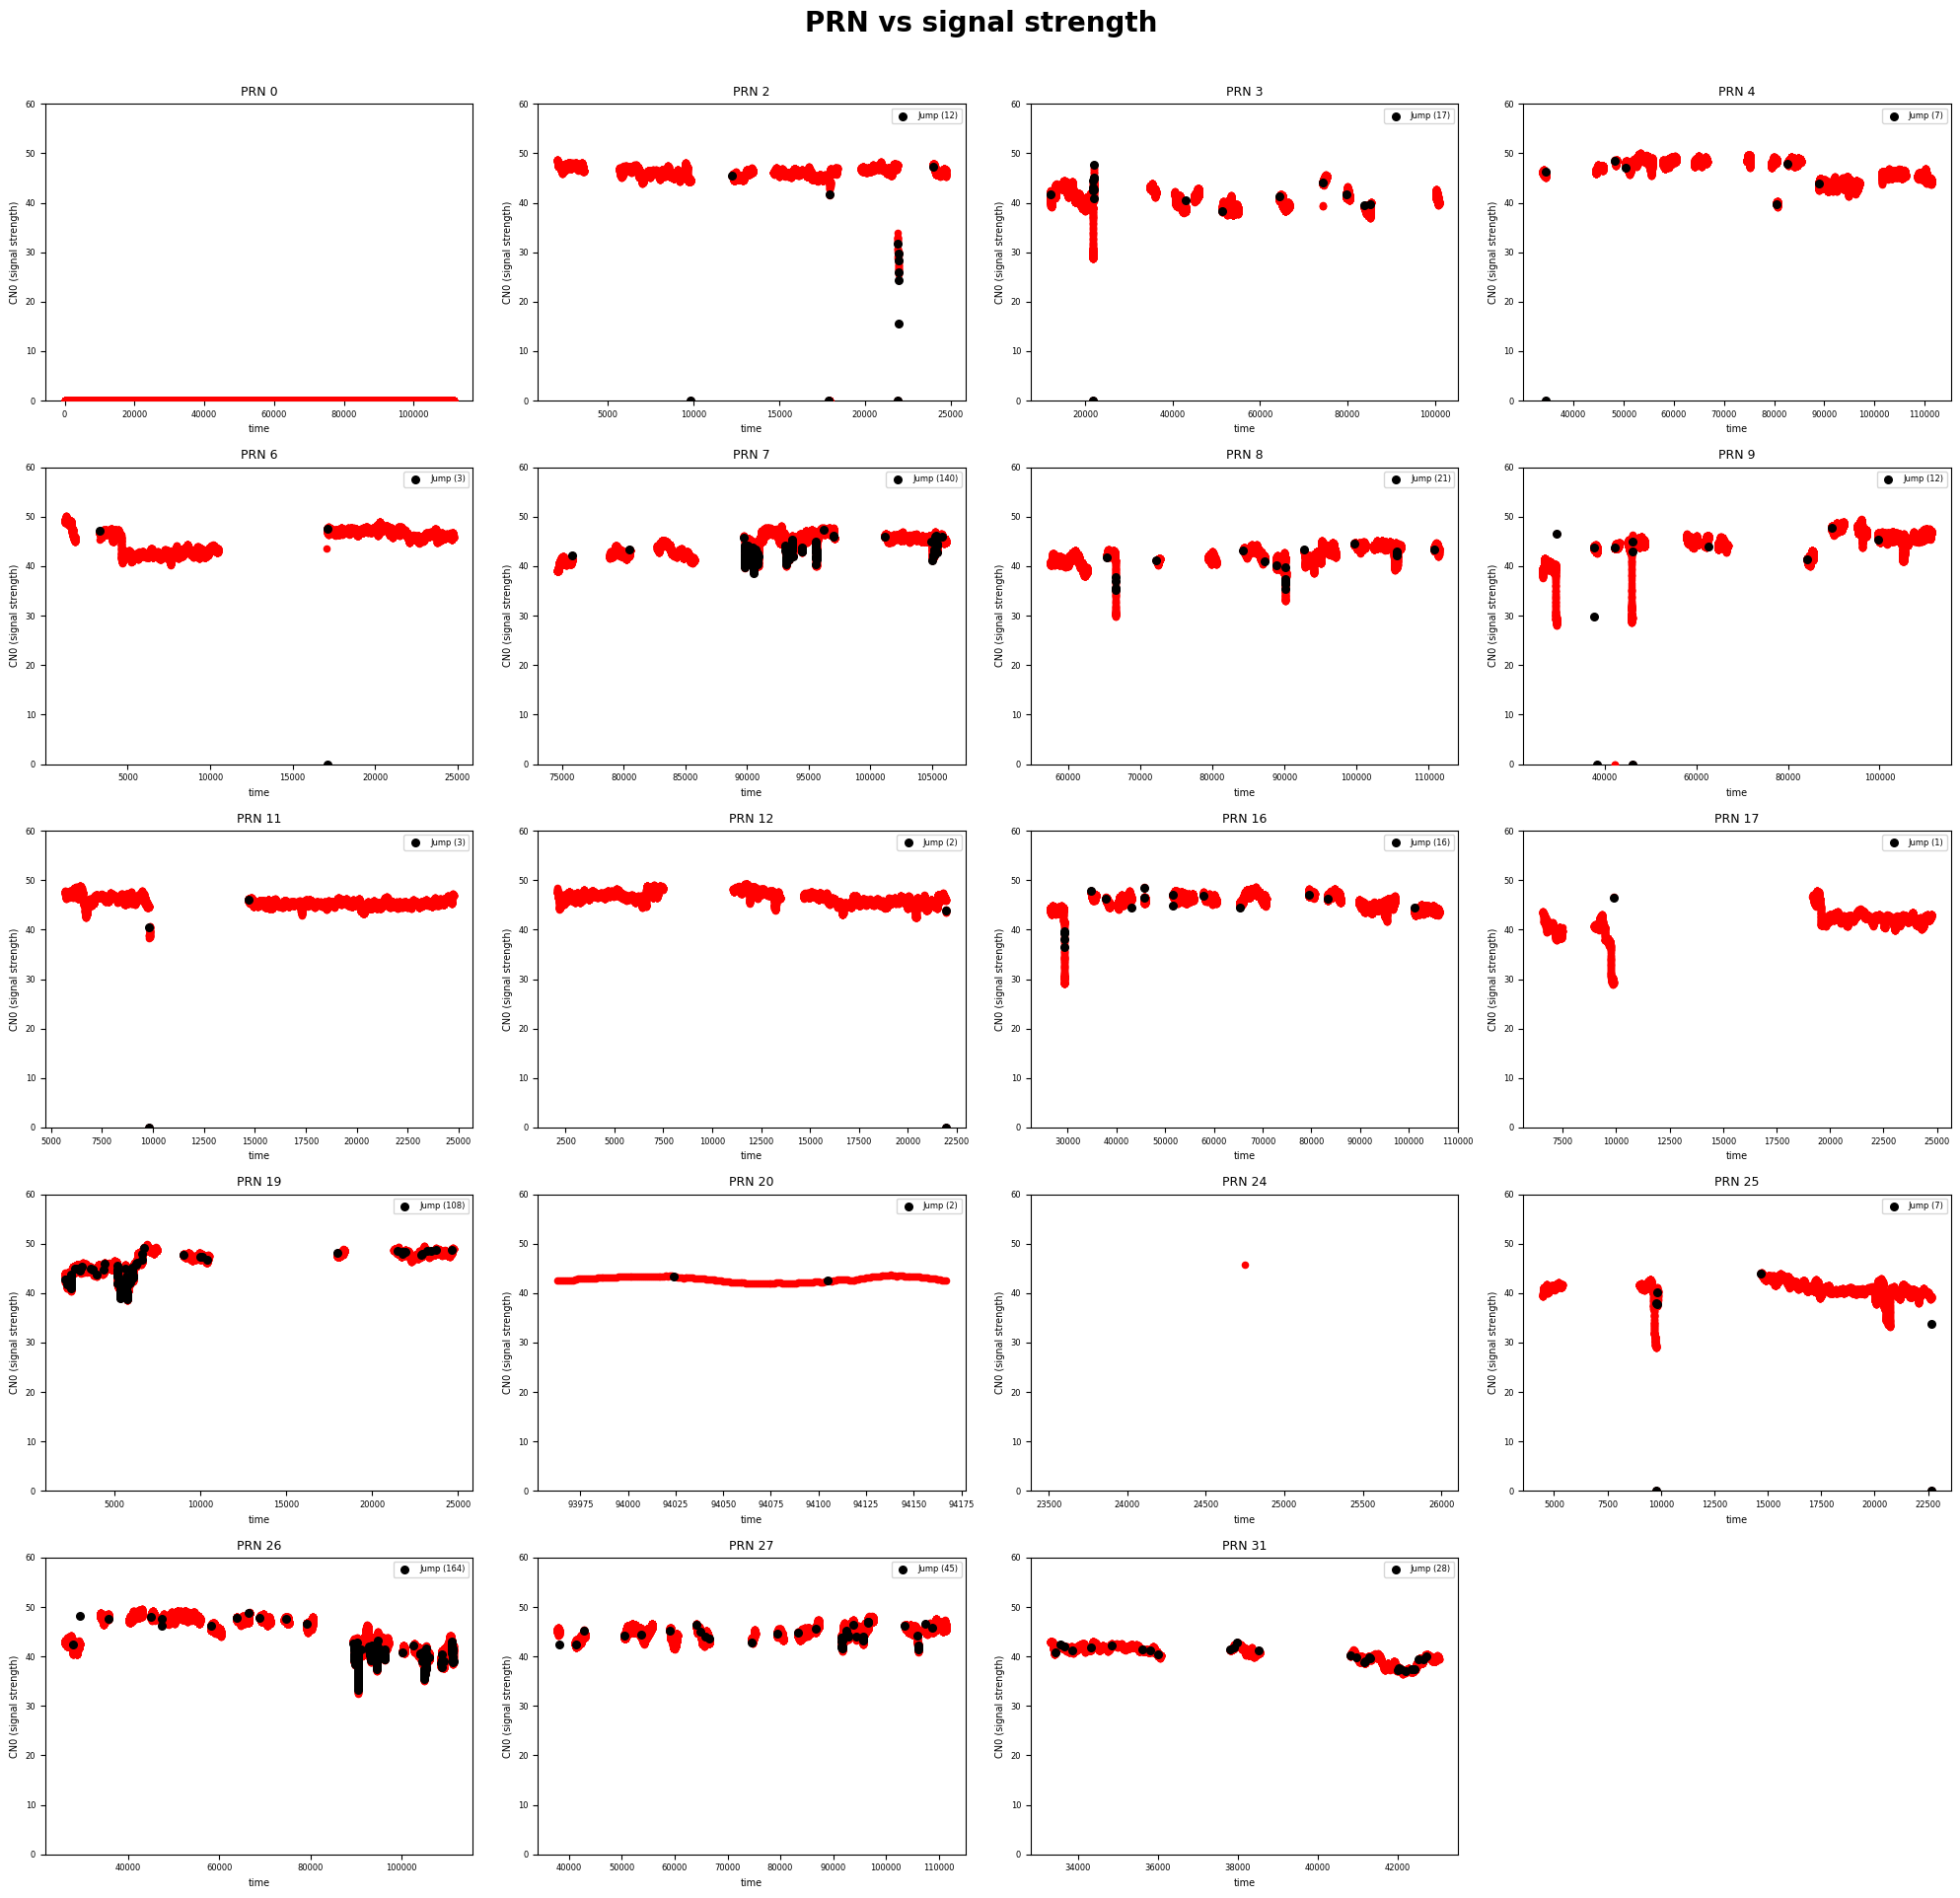

In [ ]:
# Get unique PRNs
prns = df['PRN'].unique()

fig, axes = plt.subplots(len(prns)//4 + 1, 4, figsize=(20, len(prns)))
axes = axes.flatten()

for i, prn in enumerate(sorted(prns)):
    prn_df = df[df['PRN'] == prn].sort_values('time')

    # 3-sigma jump detection (in a real life situation a jump of 3*std is highly unlikely considering normal distribution )
    cn0_diff = prn_df['CN0'].diff().abs()
    threshold = cn0_diff.mean() + 3 * cn0_diff.std()
    jumps = prn_df[cn0_diff > threshold]

    axes[i].scatter(prn_df['time'], prn_df['CN0'], color='red', s=20, zorder=5)
    axes[i].scatter(jumps['time'], jumps['CN0'], color='black', s=30, zorder=6, label=f'Jump ({len(jumps)})')

    axes[i].set_title(f'PRN {int(prn)}', fontsize=9)
    axes[i].set_xlabel('time', fontsize=7)
    axes[i].set_ylabel('CN0 (signal strength)', fontsize=7)
    axes[i].set_ylim(0, 60)  
    axes[i].tick_params(labelsize=6)
    if len(jumps) > 0:
        axes[i].legend(fontsize=6)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('PRN vs signal strength', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

When there is sudden jumps it indicates that the satellite distance suddenly increased or decreased .If there is gap 

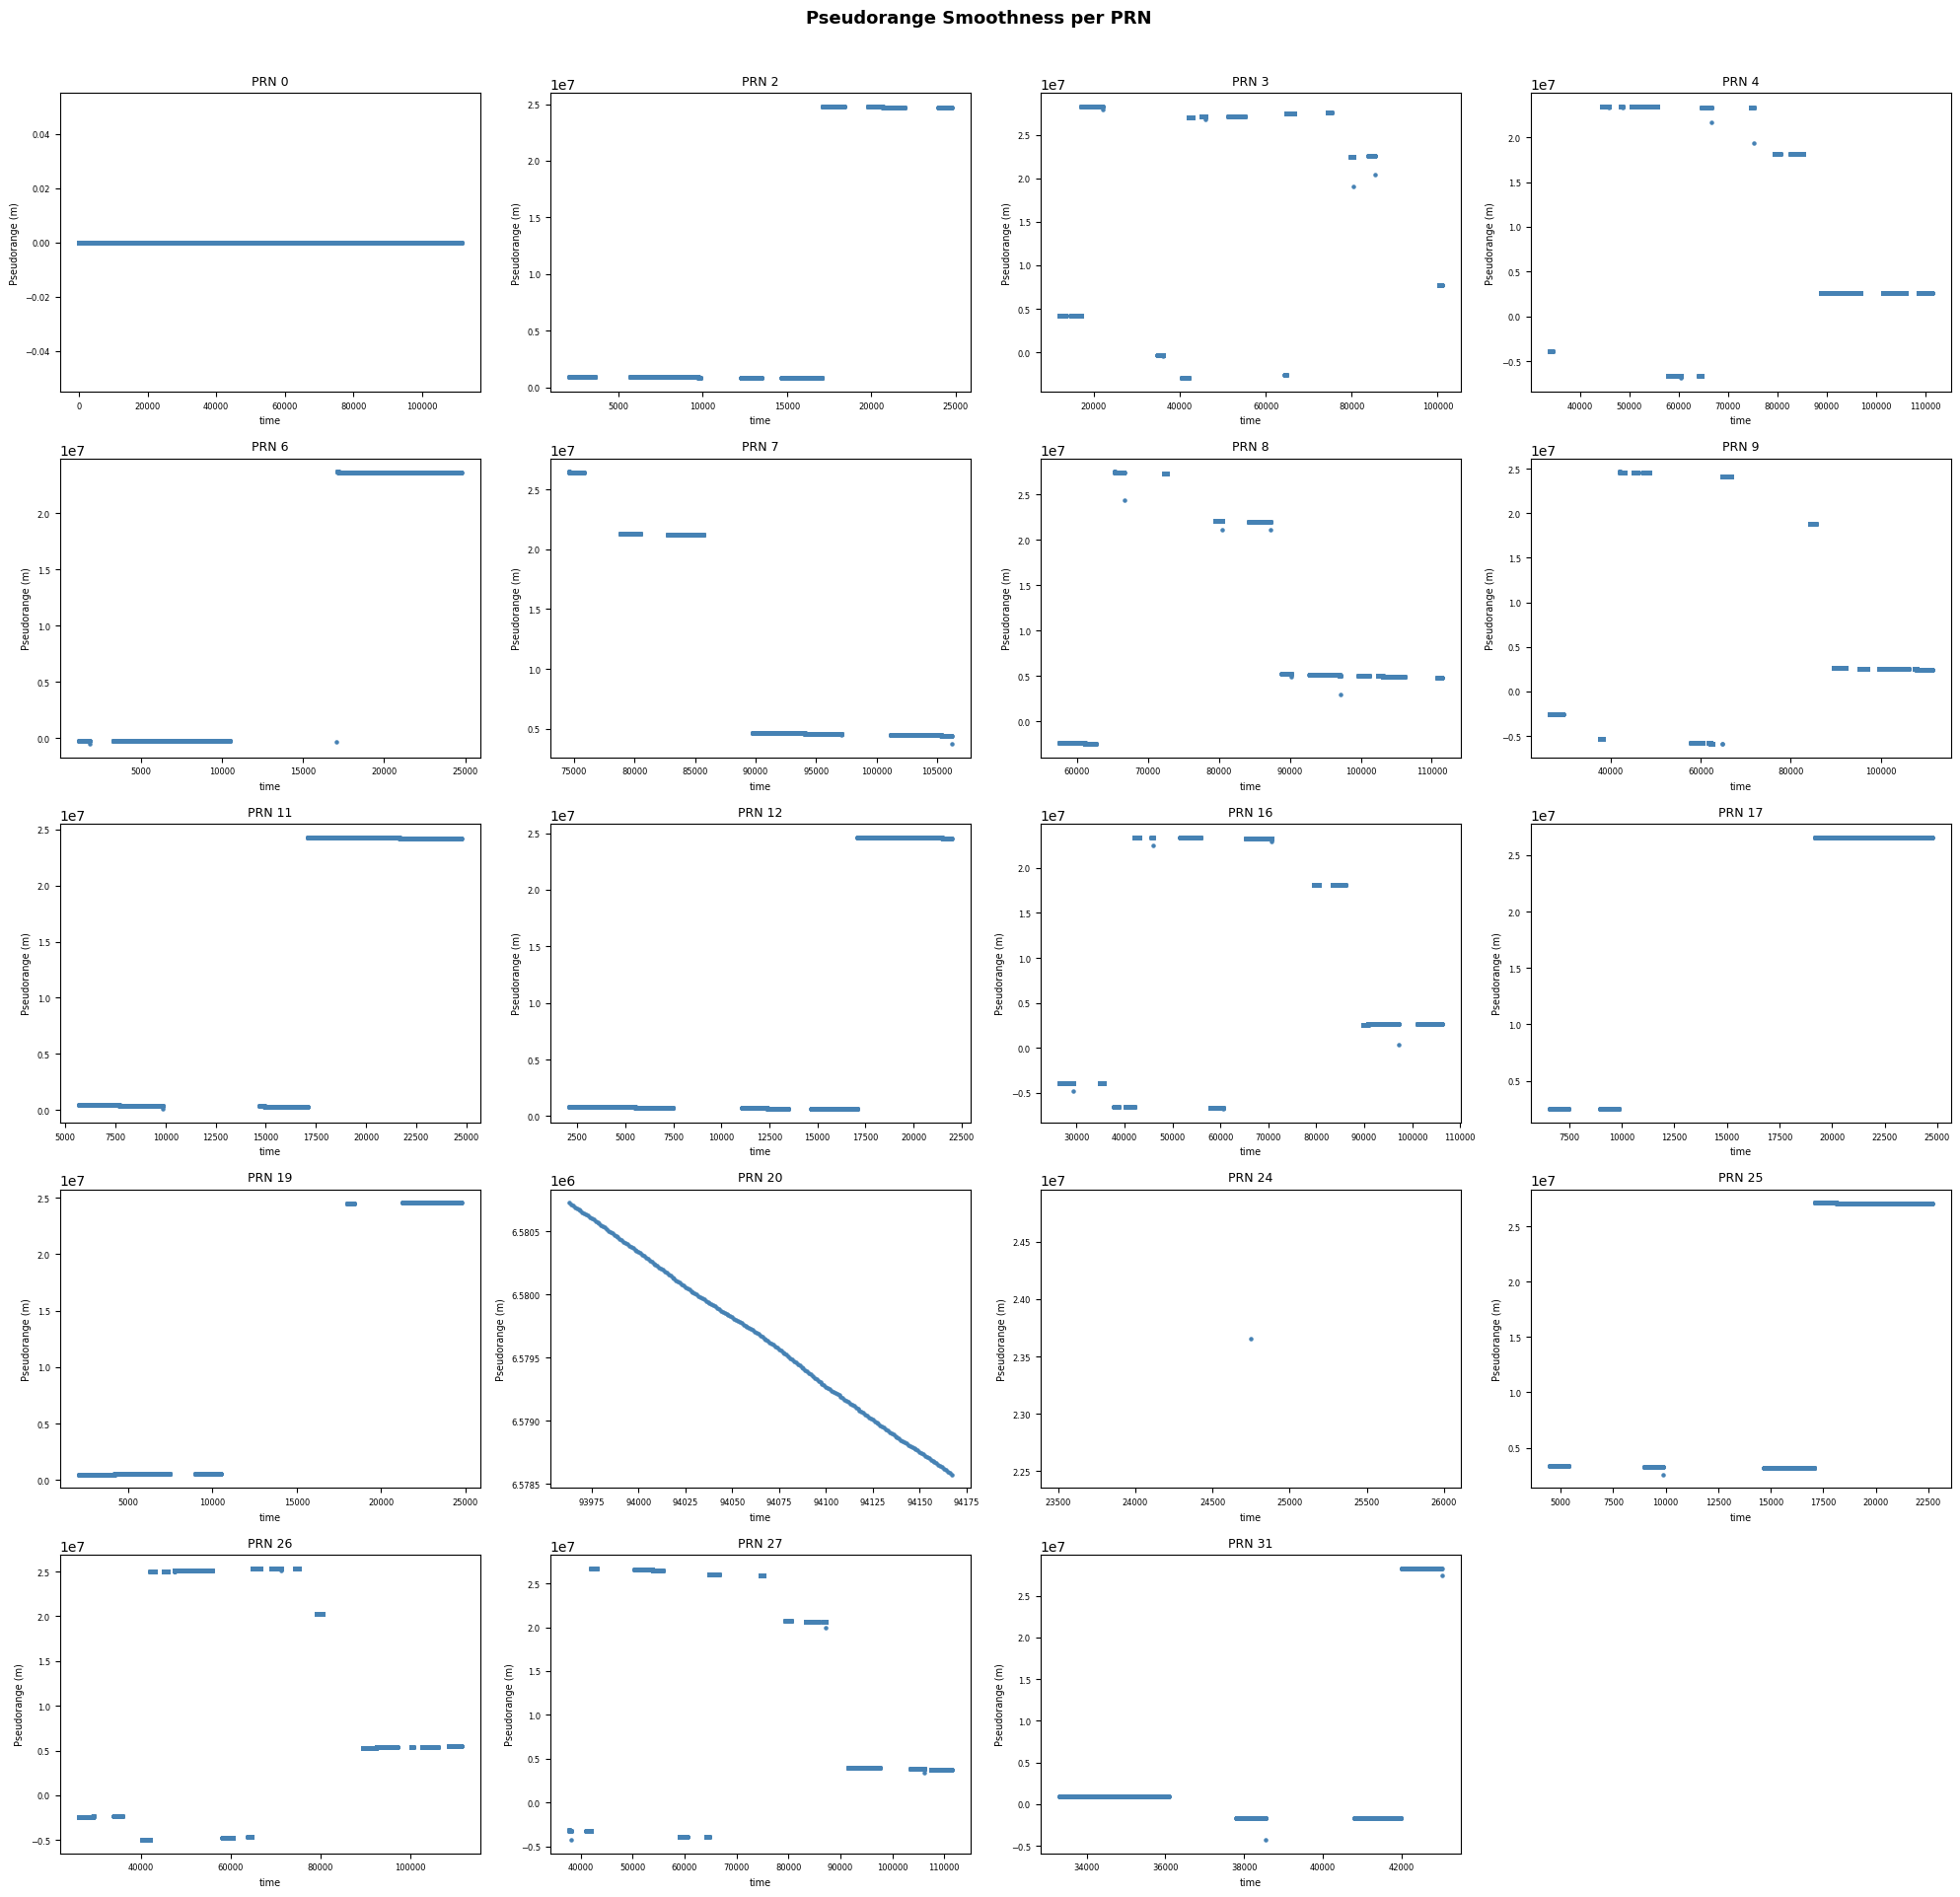

In [15]:
prns = sorted(df['PRN'].dropna().unique())

fig, axes = plt.subplots(len(prns)//4 + 1, 4, figsize=(20, len(prns)))
axes = axes.flatten()

for i, prn in enumerate(prns):
    prn_df = df[df['PRN'] == prn].sort_values('time')
    
    axes[i].scatter(prn_df['time'], prn_df['Pseudorange_m'], s=5, color='steelblue', zorder=3)
    
    axes[i].set_title(f'PRN {int(prn)}', fontsize=9)
    axes[i].set_xlabel('time', fontsize=7)
    axes[i].set_ylabel('Pseudorange (m)', fontsize=7)
    axes[i].tick_params(labelsize=6)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Pseudorange Smoothness per PRN ',fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

ajknaf


In [16]:
df['TOW_RX_diff'] = df['TOW'] - df['RX_time']

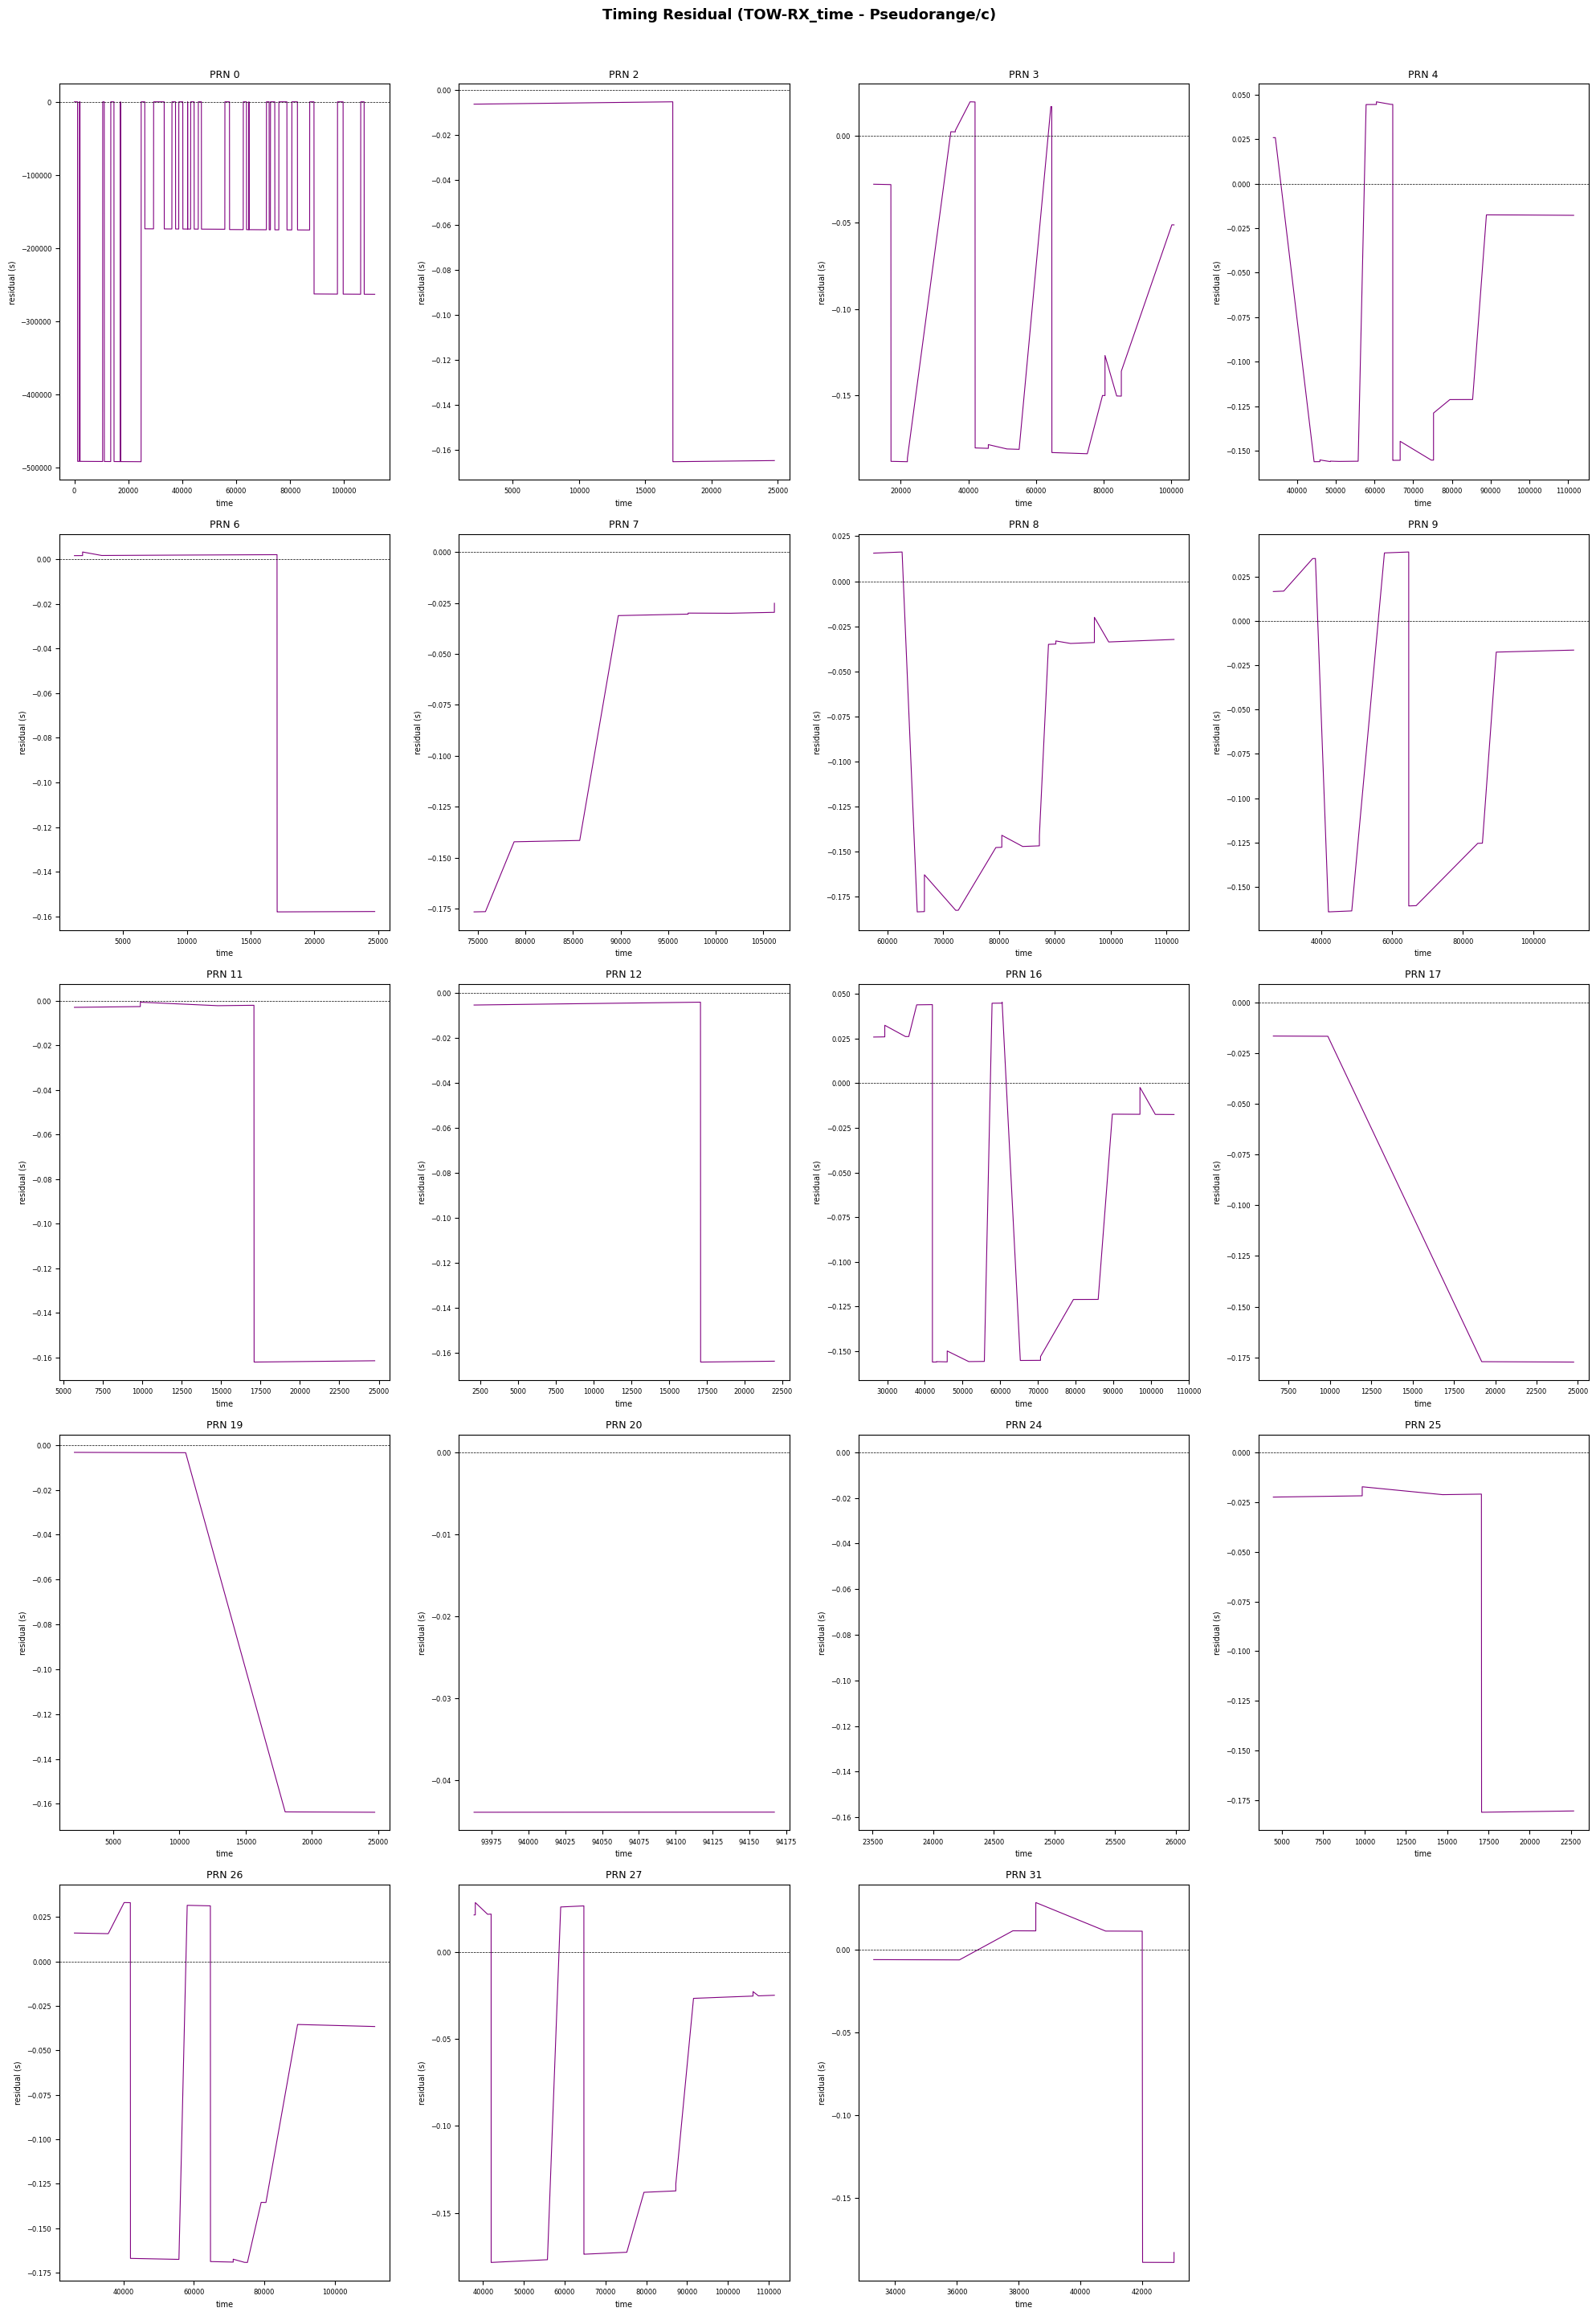

In [17]:
# Speed of light
c = 299792458  # m/s

df['TOW_RX_diff'] = df['TOW'] - df['RX_time']
df['expected_propagation'] = df['Pseudorange_m'] / c
prns = sorted(df['PRN'].dropna().unique())
# The key feature — should be near zero for genuine signals
df['timing_residual'] = df['TOW_RX_diff'] - df['expected_propagation']
fig, axes = plt.subplots(len(prns)//4 + 1, 4, figsize=(20, len(prns)*1.5))
axes = axes.flatten()

for i, prn in enumerate(prns):
    prn_df = df[df['PRN'] == prn].sort_values('time')
    residual = prn_df['timing_residual']
    
    ax = axes[i]
    ax.plot(prn_df['time'], residual, linewidth=0.8, color='purple')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')  # zero reference
    ax.set_title(f'PRN {int(prn)}', fontsize=9)
    ax.set_xlabel('time', fontsize=7)
    ax.set_ylabel('residual (s)', fontsize=7)
    ax.tick_params(labelsize=6)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Timing Residual (TOW-RX_time - Pseudorange/c)',fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

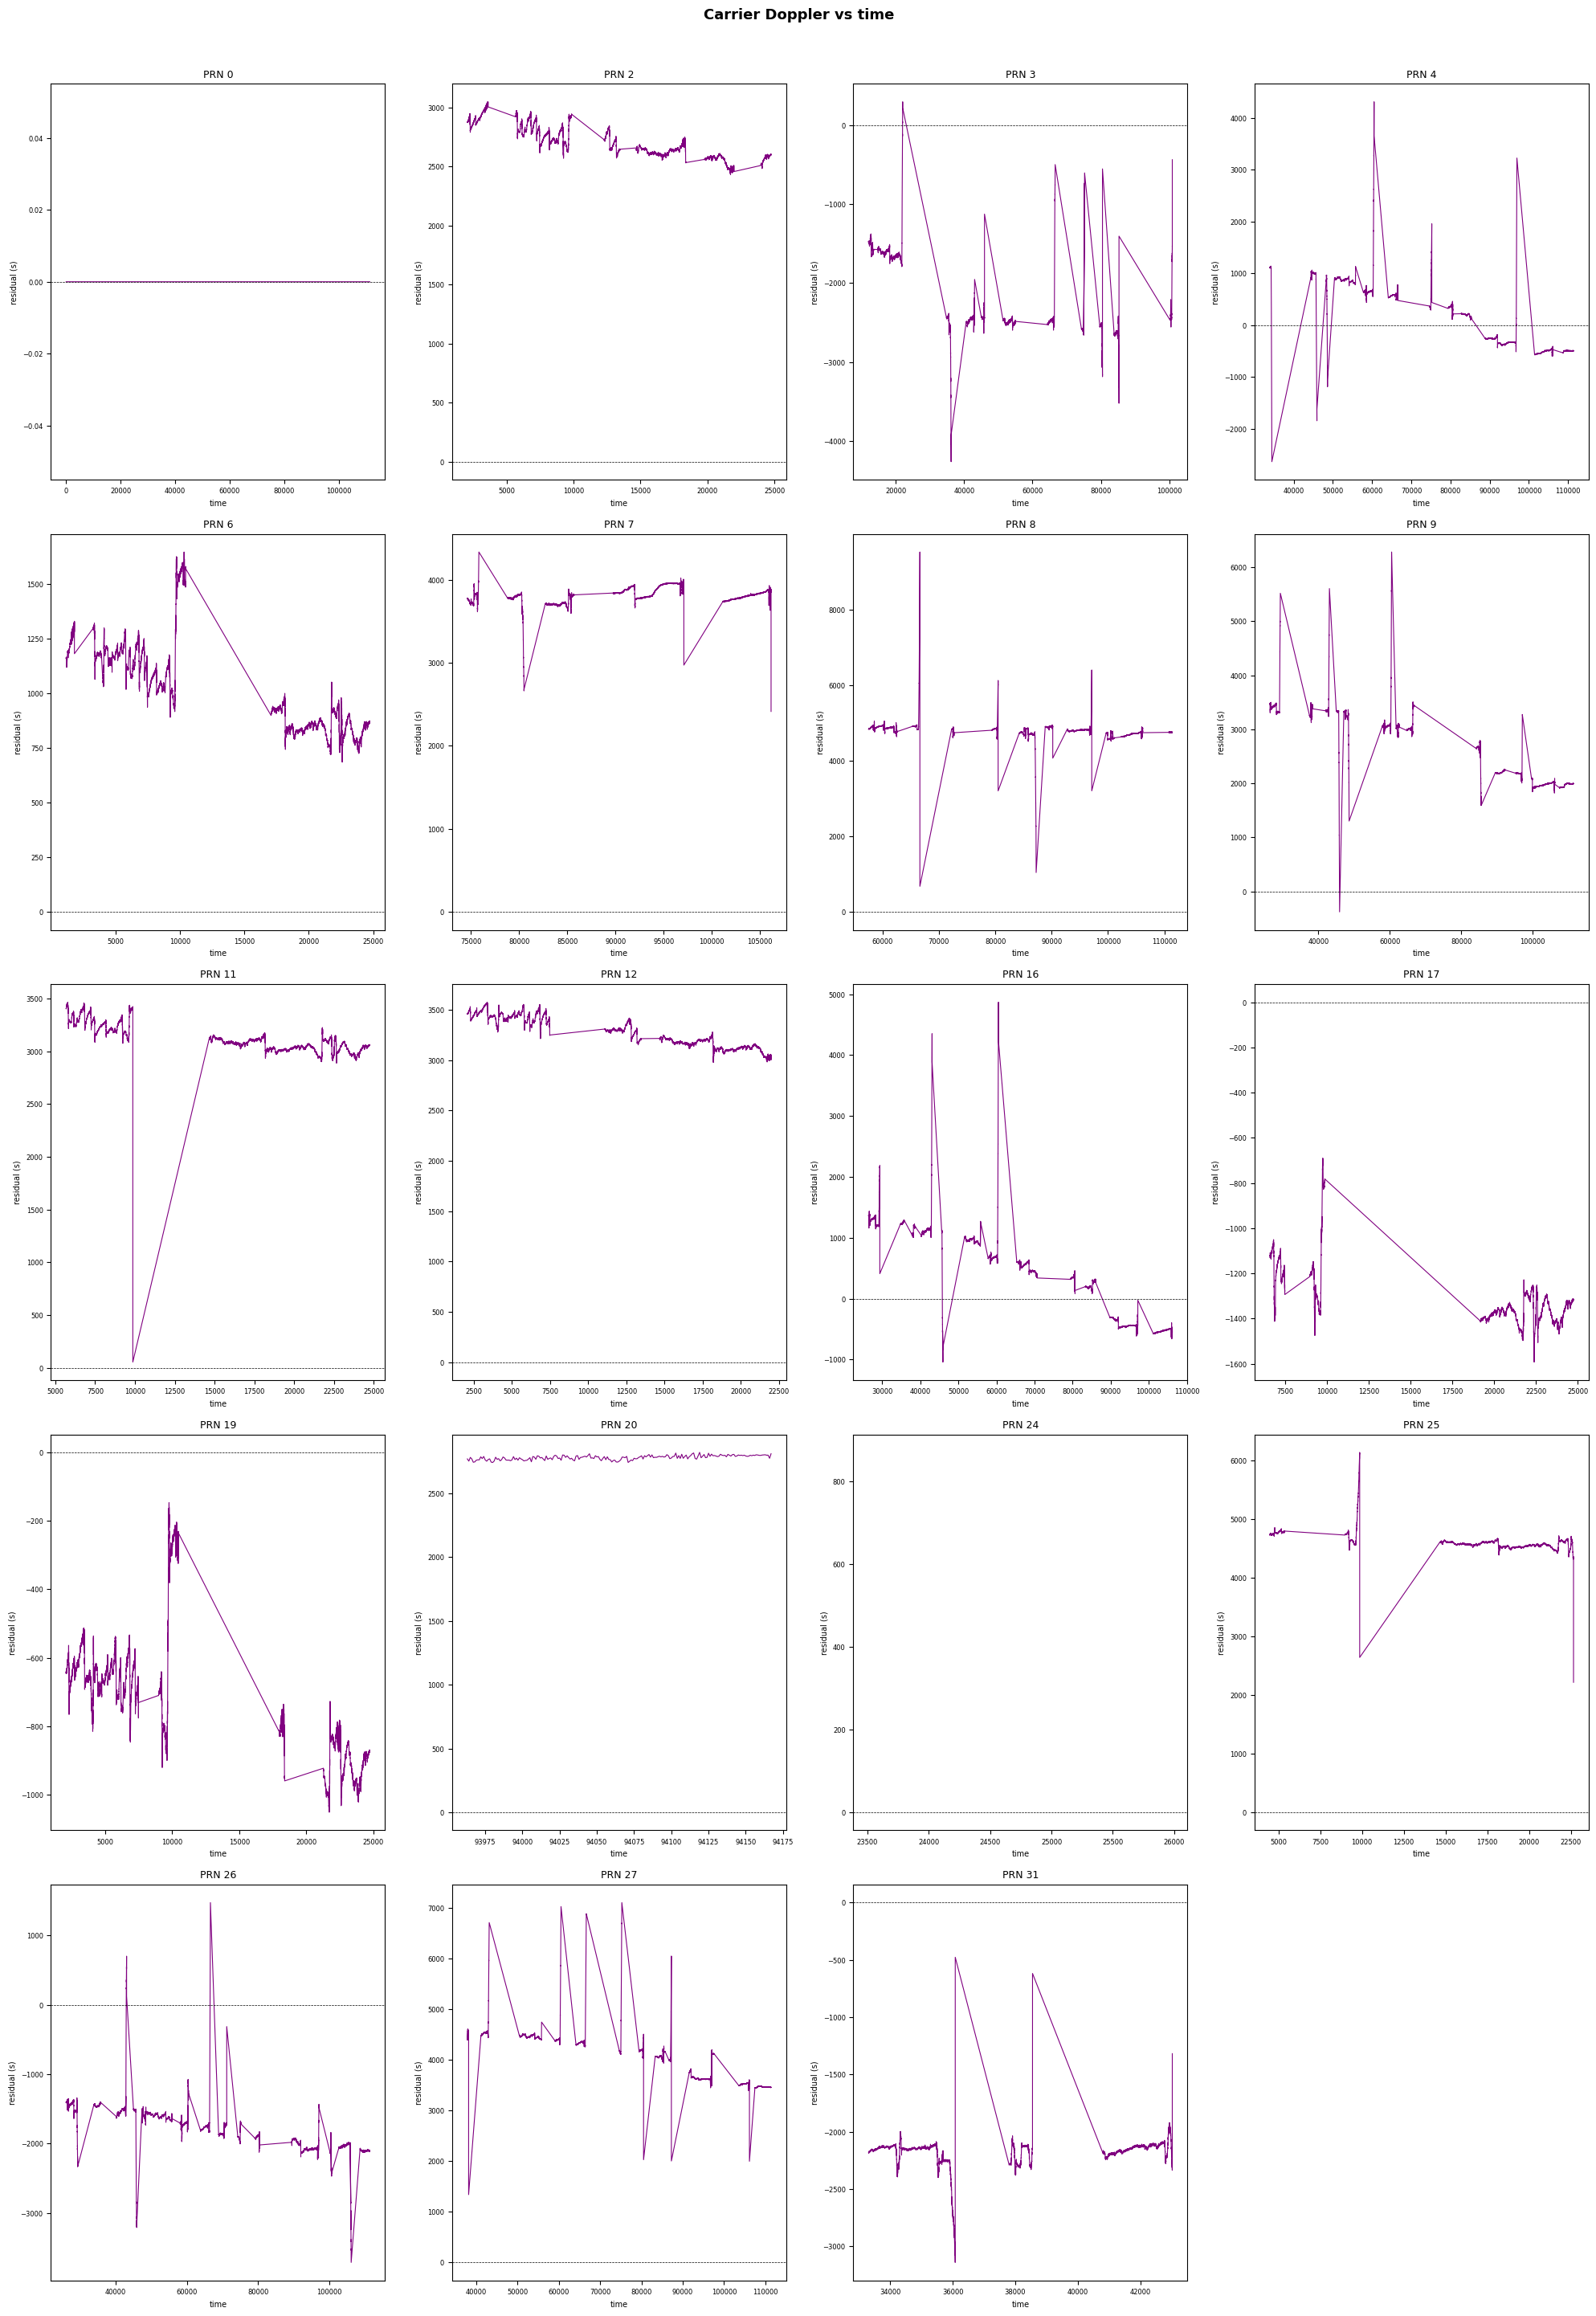

In [18]:
prns = sorted(df['PRN'].dropna().unique())
fig, axes = plt.subplots(len(prns)//4 + 1, 4, figsize=(20, len(prns)*1.5))
axes = axes.flatten()

for i, prn in enumerate(prns):
    prn_df = df[df['PRN'] == prn].sort_values('time')
    residual = prn_df['Carrier_Doppler_hz']
    
    ax = axes[i]
    ax.plot(prn_df['time'], residual, linewidth=0.8, color='purple')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')  # zero reference
    ax.set_title(f'PRN {int(prn)}', fontsize=9)
    ax.set_xlabel('time', fontsize=7)
    ax.set_ylabel('residual (s)', fontsize=7)
    ax.tick_params(labelsize=6)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Carrier Doppler vs time',fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()